# Bitcoin Analytics Capstone — Exploratory Data Analysis

**Focus:** Evaluating Prediction Market Activity as Regime-Level Signals for Bitcoin Accumulation  
**Data Sources:** Coin Metrics & Polymarket (Sponsor-Provided)

This notebook presents a narrative-driven exploratory analysis examining whether liquidity-filtered prediction market activity provides information orthogonal to traditional Bitcoin market and on-chain metrics. The goal is not price prediction, but to assess whether such signals can serve as contextual inputs for dynamic, long-only accumulation modeling.


## 1. Data Retrieval

All datasets used in this exploratory analysis were obtained using the official data retrieval script provided by the project sponsor:

https://github.com/TrilemmaFoundation/bitcoin-analytics-capstone-template/blob/main/data/download_data.py

The script was executed from the repository root. It downloads the sponsor-managed Google Drive folder and organizes all approved files into a local `data/` directory while preserving the original subfolder structure. Only supported file types (`.parquet`, `.csv`, `.md`) are retained to ensure reproducibility and consistency with the sponsor template.

To keep this notebook lightweight, deterministic, and compliant with the official workflow, we do not re-run the download step here. Instead, we assume the data have already been retrieved once using the official pipeline and proceed by verifying the expected local directory structure before conducting exploratory analysis.


In [32]:
import os
from pathlib import Path

# ---- Automatically detect repository root ----
REPO_ROOT = Path.cwd()

# If notebook is inside a subfolder (e.g., EDA/ or deliverables/), move upward until data/ is found
if not (REPO_ROOT / "data").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "data").exists():
            REPO_ROOT = parent
            break

# Fallback to your local path if running outside the repo
if not (REPO_ROOT / "data").exists():
    REPO_ROOT = Path(r"C:\Users\chen5\Documents\bitcoin-analytics-capstone")

os.chdir(REPO_ROOT)

print("Current working directory:")
print(os.getcwd())

# ---- Define data path ----
DATA_DIR = REPO_ROOT / "data"
print("Data directory exists:", DATA_DIR.exists())

# ---- Dataset-specific paths ----
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
POLYMARKET_DIR = DATA_DIR / "Polymarket"

print("Coin Metrics file exists:", COINMETRICS_PATH.exists())
print("Polymarket dir exists:", POLYMARKET_DIR.exists())


Current working directory:
C:\Users\chen5\Documents\bitcoin-analytics-capstone
Data directory exists: True
Coin Metrics file exists: True
Polymarket dir exists: True


## 2. General Dataset Overview

This section provides a high-level validation of the datasets used in this exploratory analysis. The goal is to confirm structural integrity, temporal coherence, and completeness before conducting cross-feature exploratory analysis.

Two sponsor-provided data sources are used:

- **Coin Metrics**: Daily Bitcoin market and on-chain metrics (UTC daily cadence)
- **Polymarket**: Prediction market markets metadata and odds history (high-frequency updates later aggregated to daily)

The emphasis here is on data integrity and time coverage, not feature engineering or predictive modeling.


### 2.1 Coin Metrics Validation

Bitcoin market and on-chain data are sourced from Coin Metrics. The dataset is reported at a daily cadence and spans the full history of Bitcoin across multiple market cycles.

At this stage, the objective is to validate:

- Time coverage and continuity (no missing calendar days)
- Basic structure (rows/columns)
- Sanity checks for key variables (value ranges, descriptive statistics)
- Descriptive correlation context among a small set of core metrics

These checks establish the baseline market structure against which any external signal (e.g., prediction market activity) must demonstrate incremental or orthogonal informational value.


In [33]:
import pandas as pd

btc_df = pd.read_csv(COINMETRICS_PATH)
btc_df["time"] = pd.to_datetime(btc_df["time"])

print(
    "Rows:", btc_df.shape[0],
    "| Columns:", btc_df.shape[1],
    "| Missing days:",
    len(
        pd.date_range(
            btc_df["time"].min(),
            btc_df["time"].max(),
            freq="D"
        ).difference(btc_df["time"])
    )
)


Rows: 6221 | Columns: 32 | Missing days: 0


**Key checks**

- The dataset contains daily observations with a continuous date index (no missing calendar days).
- Columns cover price, market capitalization, network activity, and exchange flows.

Note: While the date index is continuous, some individual metrics may contain missing values in early Bitcoin history. Summary statistics are computed column-wise after dropping NaNs.


In [34]:
btc_df[["PriceUSD", "TxCnt", "HashRate"]].describe().round(2)


,PriceUSD,TxCnt,HashRate
count,5659.00,6220.00,6.214000e+03
mean,19809.99,208414.23,1.514551e+08
std,29699.08,170293.82,2.634492e+08
min,0.05,0.00,0.000000e+00
25%,260.58,47152.50,6.284000e+01
50%,5728.35,224415.50,5.567322e+06
75%,28820.68,312607.50,1.652824e+08
max,124824.45,928131.00,1.305500e+09


**Bitcoin Price History (Log Scale)**

To establish long-horizon market context, we visualize Bitcoin’s full price history using a logarithmic scale. This highlights regime shifts while preserving early-period dynamics.


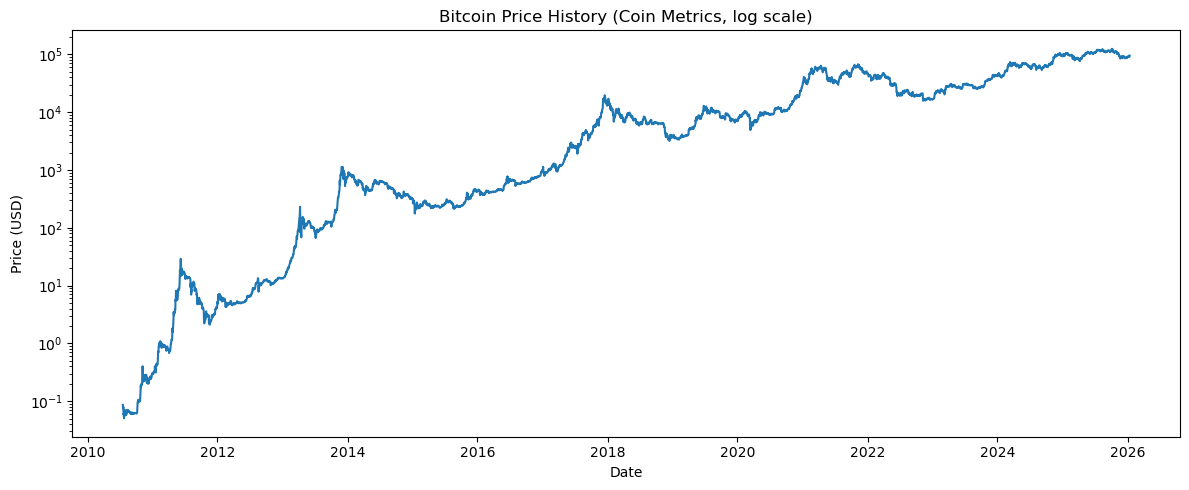

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(btc_df["time"], btc_df["PriceUSD"])
plt.yscale("log")
plt.title("Bitcoin Price History (Coin Metrics, log scale)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()


**High-Level Correlations Among Core Metrics**

As a final structural check, we examine correlations among a small set of core market and network variables. This step provides descriptive context rather than causal inference.


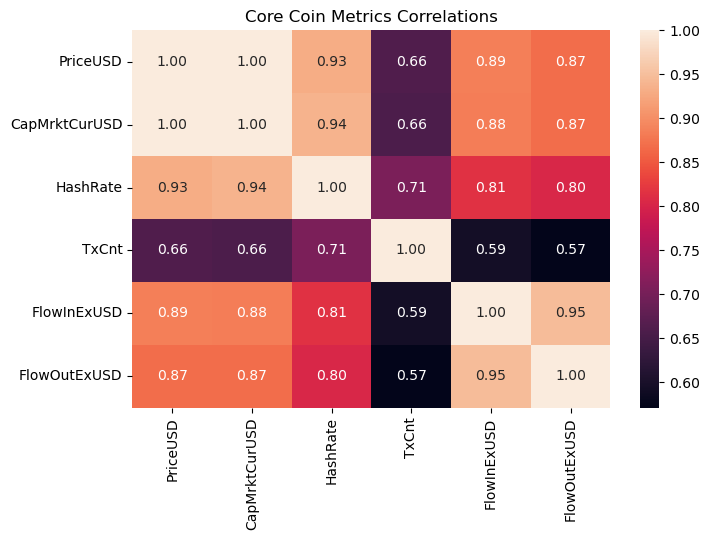

In [36]:
import seaborn as sns

core_cols = [
    "PriceUSD",
    "CapMrktCurUSD",
    "HashRate",
    "TxCnt",
    "FlowInExUSD",
    "FlowOutExUSD",
]
core_cols = [c for c in core_cols if c in btc_df.columns]

corr = btc_df[core_cols].dropna().corr()

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Core Coin Metrics Correlations")
plt.tight_layout()
plt.show()


**Section takeaway**

The Coin Metrics dataset provides a complete, long-horizon view of Bitcoin’s market and on-chain behavior with consistent daily coverage. This establishes a reliable baseline against which prediction-market-derived signals can be evaluated in later sections.


### 2.2 Polymarket Validation

Polymarket provides trading activity and probability dynamics for prediction markets spanning finance and politics. In this project, it serves as a complementary information source reflecting market-implied beliefs and participant behavior around macro and Bitcoin-adjacent events.

The objective of this section is to validate:

- Dataset scale and structural integrity (markets table + odds history)
- Probability value sanity checks (prices within [0, 1])
- Timestamp integrity (critical to prevent silent look-ahead bias)
- Confirmed alignment with the sponsor’s updated official loader


In [37]:
pm_markets = pd.read_parquet(POLYMARKET_DIR / "finance_politics_markets.parquet")
pm_odds = pd.read_parquet(POLYMARKET_DIR / "finance_politics_odds_history.parquet")

pm_markets["created_at"] = pd.to_datetime(pm_markets["created_at"])
pm_markets["end_date"] = pd.to_datetime(pm_markets["end_date"])

print("Markets table:", pm_markets.shape)
print("Odds history table:", pm_odds.shape)


Markets table: (78321, 10)
Odds history table: (2143181, 4)


In [38]:
print("Unique markets:", pm_markets["market_id"].nunique())
print("Unique events:", pm_markets["event_slug"].nunique())

pm_odds[["price"]].describe()


Unique markets: 78321
Unique events: 44033


,price
count,2.143181e+06
mean,5.000062e-01
std,3.909961e-01
min,5.000000e-04
25%,6.750000e-02
50%,5.000000e-01
75%,9.325000e-01
max,1.000000e+00


**Timestamp Integrity: Independent Detection & Validation**

Initial direct inspection of the raw odds timestamps revealed an anomaly (dates appearing in 1970), which is inconsistent with Polymarket’s operational history and indicates a timestamp unit encoding issue.

Because timestamp integrity directly impacts temporal alignment and leakage safety, we explicitly validate and correct this issue before any aggregation.


In [39]:
print(
    "Raw odds time range:",
    pm_odds["timestamp"].min(),
    "→",
    pm_odds["timestamp"].max()
)


Raw odds time range: 1970-01-20 09:08:38.412000 → 1970-01-21 10:59:34.930000


In [40]:
# ---- Fix odds timestamps (epoch milliseconds) ----
ts_ms = pd.to_numeric(pm_odds["timestamp"], errors="coerce")

pm_odds["timestamp_fixed"] = pd.to_datetime(ts_ms, unit="ms", utc=True)
pm_odds["date"] = pm_odds["timestamp_fixed"].dt.date

print(
    "Fixed odds time range:",
    pm_odds["timestamp_fixed"].min(),
    "→",
    pm_odds["timestamp_fixed"].max()
)
print("Unique days:", pm_odds["date"].nunique())


Fixed odds time range: 2023-01-24 00:00:12+00:00 → 2026-01-05 01:02:10+00:00
Unique days: 1066


**Sponsor Loader Verification**

The project sponsor subsequently updated the official loader to automatically correct malformed timestamp units. We verify that the sponsor implementation produces identical temporal coverage, confirming that:

- The anomaly was correctly identified
- The correction logic is consistent with sponsor-approved utilities
- Downstream aggregation and alignment are leakage-safe


In [41]:
from eda.eda_starter_template import load_polymarket_data
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\chen5\Documents\bitcoin-analytics-capstone")
POLYMARKET_DIR = PROJECT_ROOT / "data" / "Polymarket"

poly_data = load_polymarket_data(POLYMARKET_DIR)

official_odds = poly_data["odds"]

print(
    "Official loader time range:",
    official_odds["timestamp"].min(),
    "→",
    official_odds["timestamp"].max()
)

import polars as pl

print(
    "Official unique days:",
    official_odds.select(
        pl.col("timestamp").dt.date().n_unique()
    ).item()
)


Loading Polymarket data from C:\Users\chen5\Documents\bitcoin-analytics-capstone\data\Polymarket...
[Memory] Before loading Polymarket data: 352.09 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 543.17 MB (Δ 191.08 MB)
Official loader time range: 2023-01-24 00:00:12 → 2026-01-05 01:02:10
Official unique days: 1066


**Odds Update Density (Daily)**

As a final validation step, we examine the daily density of odds updates. Dense and continuous activity supports aggregation to daily frequency without relying on sparse sampling.


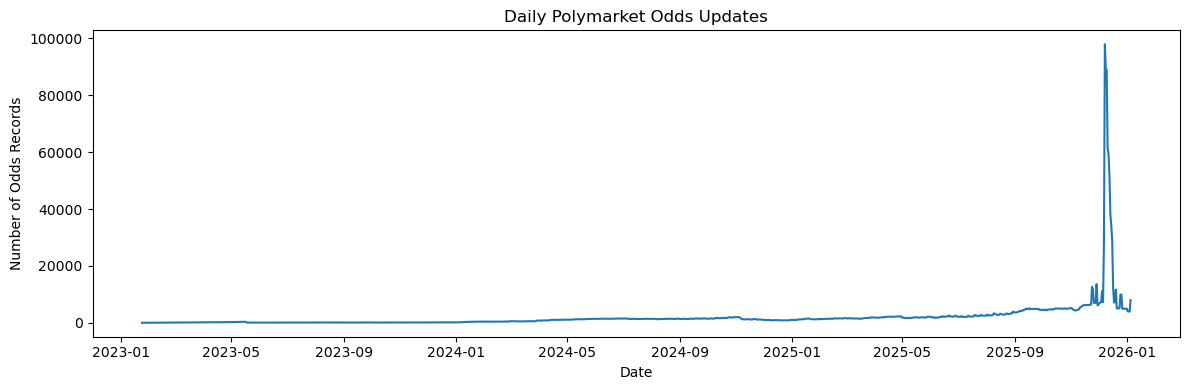

In [42]:
odds_daily = (
    pm_odds
    .groupby("date")
    .size()
)

plt.figure(figsize=(12, 4))
plt.plot(odds_daily.index, odds_daily.values)
plt.title("Daily Polymarket Odds Updates")
plt.xlabel("Date")
plt.ylabel("Number of Odds Records")
plt.tight_layout()
plt.show()


**Section takeaway**

The Polymarket dataset provides large-scale market coverage and well-formed probability values. After independent anomaly detection and cross-verification with the sponsor’s updated loader, timestamp integrity is confirmed.

The dataset can therefore be safely aggregated to daily frequency and aligned with Bitcoin market metrics without introducing temporal leakage.


## 3. Prediction Market Feature Construction

Having validated data integrity and temporal alignment, this section constructs daily prediction-market-derived features suitable for alignment with Bitcoin market data.

Raw Polymarket odds history contains over two million high-frequency updates across tens of thousands of markets with highly uneven liquidity. Direct aggregation across all markets would introduce substantial microstructure noise from thinly traded contracts.

Therefore, this section focuses on transforming raw odds history into stable, interpretable daily features using a liquidity-based filtering approach.


### 3.1 Smart Money Filtering

Polymarket contains more than 78,000 markets with highly uneven trading activity. Many markets exhibit sparse updates and low liquidity, which can introduce noise when constructing daily aggregate signals.

To improve aggregation reliability, we apply a liquidity-based filtering strategy.

**Operational definition ("smart money")**

In this notebook, "smart money" refers to the highest-liquidity subset of markets, specifically the top 100 markets ranked by total trading volume. This designation is purely operational:

- High-liquidity markets exhibit denser price updates
- Daily aggregates are more stable
- Signals are less influenced by thin-market microstructure noise

This terminology does not imply verified investor sophistication; it is strictly a liquidity-based filtering convention.

From this filtered subset, we construct three daily features:

- **smart_odds_updates**: number of odds updates (attention / uncertainty proxy)
- **smart_mean_price**: average probability level (contextual signal)
- **smart_price_std**: dispersion of probabilities (belief divergence proxy)


In [43]:
# ---- Filter for Top 100 Liquid Markets ----
top_volume_ids = pm_markets.nlargest(100, "volume")["market_id"]

# Filter the odds history to include ONLY these markets
pm_odds_filtered = pm_odds[pm_odds["market_id"].isin(top_volume_ids)]

# ---- Refined Daily Aggregation ----
pm_daily_refined = (
    pm_odds_filtered
    .groupby("date")
    .agg(
        smart_odds_updates=("price", "size"),
        smart_mean_price=("price", "mean"),
        smart_price_std=("price", "std")
    )
    .reset_index()
)

print("Refined Daily Features (Top 100 Markets):")
print(pm_daily_refined.head())
print("Shape:", pm_daily_refined.shape)


Refined Daily Features (Top 100 Markets):
         date  smart_odds_updates  smart_mean_price  smart_price_std
0  2024-01-05                  10               0.5         0.000000
1  2024-01-06                  18               0.5         0.423033
2  2024-01-07                  22               0.5         0.441671
3  2024-01-08                  22               0.5         0.445177
4  2024-01-09                  22               0.5         0.445677
Shape: (732, 4)


Across most days, the average probability level remains close to 0.5 due to the binary-outcome structure of prediction markets and cross-market averaging effects.

Accordingly:

- Mean price levels are treated as contextual signals
- Activity and dispersion features are emphasized for downstream analysis

The resulting dataset provides stable daily coverage suitable for alignment with Bitcoin metrics.


### 3.2 Daily Alignment with Bitcoin Data

To enable cross-feature exploratory analysis, the refined Polymarket features are aligned with daily Bitcoin market and on-chain metrics.

Alignment is performed using an inner join on calendar dates to ensure that:

- All observations correspond to days with both Bitcoin data and prediction market activity
- No implicit forward-looking information is introduced

This aligned dataset forms the primary table used in subsequent exploratory analysis.


In [44]:
# ---- Prepare daily Bitcoin table ----
btc_daily = (
    btc_df
    .assign(date=btc_df["time"].dt.date)
    .set_index("date")
    .sort_index()
)

# ---- Align Refined Datasets ----
pm_daily_idx = pm_daily_refined.set_index("date").sort_index()

aligned_df = (
    btc_daily
    .join(pm_daily_idx, how="inner")
    .sort_index()
)

print("Aligned dataset shape:", aligned_df.shape)

# Fill NaN for days where top markets might not have updates
aligned_df = aligned_df.ffill()

aligned_df.head()


Aligned dataset shape: (732, 35)


,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,smart_odds_updates,smart_mean_price,smart_price_std
date,,,,,,,,,,,,,,,,,,,,,
2024-01-05,2024-01-05,813324.0,52185685.0,1.704516e+09,1.704516e+09,138.0,1.983754,8.648562e+11,8.648256e+11,117.053818,...,1.959067e+07,1.613480e+06,7.122922e+10,2.074230e+07,416347.0,1025361.0,1.458810e+10,10,0.5,0.000000
2024-01-06,2024-01-06,808917.0,52182777.0,1.704603e+09,1.704603e+09,140.0,1.972627,8.604213e+11,8.603906e+11,85.704167,...,1.959155e+07,1.608179e+06,7.062797e+10,2.074241e+07,389306.0,917220.0,6.247901e+09,18,0.5,0.423033
2024-01-07,2024-01-07,713381.0,52185360.0,1.704691e+09,1.704691e+09,118.0,1.968589,8.590081e+11,8.589834e+11,76.090663,...,1.959229e+07,1.607342e+06,7.047262e+10,2.074250e+07,348435.0,813606.0,7.431340e+09,22,0.5,0.441671
2024-01-08,2024-01-08,756849.0,52192671.0,1.704773e+09,1.704773e+09,123.0,2.105200,9.205077e+11,9.204798e+11,128.016504,...,1.959306e+07,1.612735e+06,7.576842e+10,2.074260e+07,409400.0,900572.0,1.854234e+10,22,0.5,0.445177
2024-01-09,2024-01-09,902934.0,52162780.0,1.704863e+09,1.704863e+09,152.0,2.061112,9.029703e+11,9.029346e+11,110.412549,...,1.959401e+07,1.618416e+06,7.458308e+10,2.074272e+07,470829.0,1065162.0,1.915526e+10,22,0.5,0.445677


The resulting aligned dataset contains daily observations covering the overlapping period between Bitcoin metrics and high-liquidity prediction market activity.

This table integrates:

- Bitcoin market and on-chain features
- Aggregated prediction market activity signals

and serves as the primary input for cross-feature exploratory analysis in the following section.


## 4. Cross-Feature Exploratory Analysis

This section evaluates whether prediction-market-derived signals provide meaningful information when analyzed alongside Bitcoin market and on-chain metrics.

The objective is not price prediction. Instead, the focus is on identifying whether prediction market activity can serve as a contextual conditioning signal for dynamic, long-only Bitcoin accumulation strategies.

We investigate three key aspects:

- Co-movement between prediction market activity and Bitcoin price regimes
- Statistical relationships and robustness checks
- Whether activity regimes align with accumulation efficiency conditions


### 4.1 Co-movement Visualization

To assess whether prediction market activity exhibits meaningful co-movement with Bitcoin market dynamics, we visualize Bitcoin price and high-liquidity prediction market activity using a dual-axis time series plot.

- Left axis: Bitcoin price (log scale)
- Right axis: smart_odds_updates (prediction market activity)

This visualization provides an intuitive view of regime-level relationships.


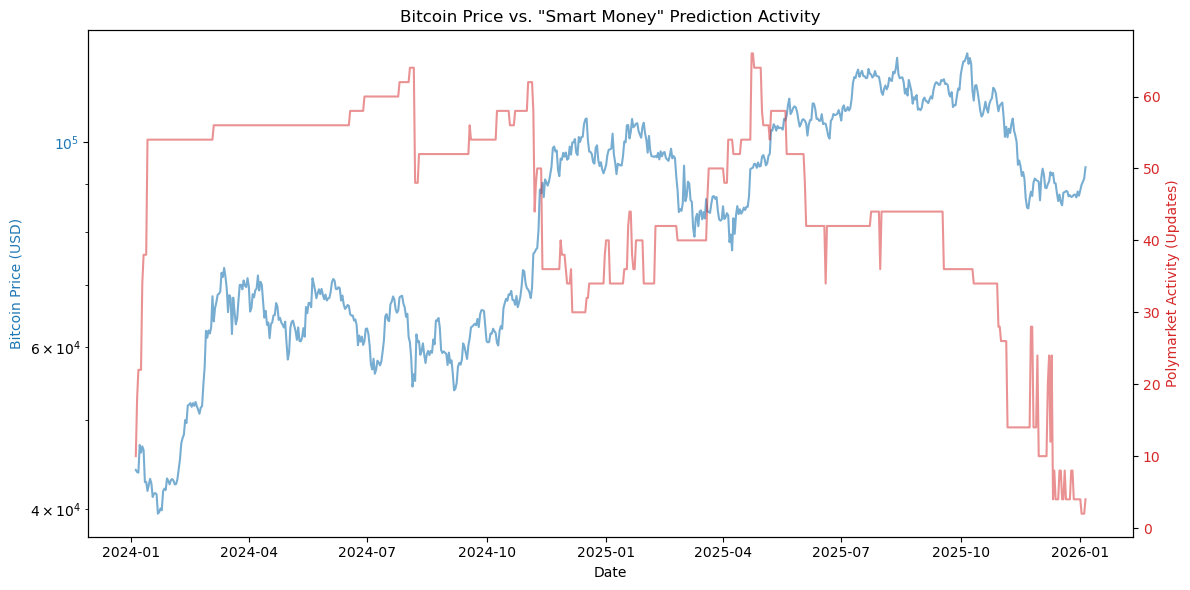

In [45]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# BTC price
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Bitcoin Price (USD)', color=color)
ax1.plot(
    aligned_df.index,
    aligned_df['PriceUSD'],
    color=color,
    alpha=0.6,
    label='BTC Price'
)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Prediction market activity
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Polymarket Activity (Updates)', color=color)
ax2.plot(
    aligned_df.index,
    aligned_df['smart_odds_updates'],
    color=color,
    alpha=0.5,
    label='Polymarket Activity'
)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Bitcoin Price vs. "Smart Money" Prediction Activity')
plt.tight_layout()
plt.show()


Periods of pronounced Bitcoin regime transitions are often accompanied by elevated prediction market activity.

Activity spikes tend to occur during major price movements or structural shifts, suggesting that participation intensity reflects market attention or uncertainty rather than short-term directional signals.

This observation motivates further statistical analysis of the relationship between activity and Bitcoin market conditions.


### 4.2 Correlation Structure & Robustness Checks

We examine statistical relationships between Bitcoin metrics and prediction market activity to determine whether these signals:

- Provide information beyond traditional market indicators
- Reflect short-term momentum or volatility
- Capture longer-horizon regime-level structure


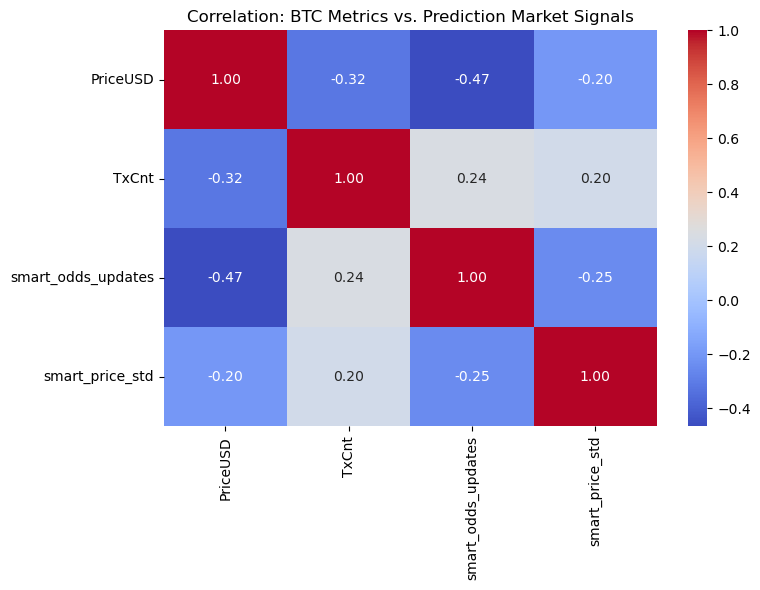

In [46]:

check_cols = [
    'PriceUSD',
    'TxCnt',
    'smart_odds_updates',
    'smart_price_std'
]

corr_matrix = aligned_df[check_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation: BTC Metrics vs. Prediction Market Signals")
plt.tight_layout()
plt.show()


In [47]:
# Returns vs activity
corr_robust = aligned_df['PriceUSD'].pct_change().corr(
    aligned_df['smart_odds_updates']
)
print(f"Correlation (Returns vs Activity): {corr_robust}")

# Volatility vs activity
corr_vol = aligned_df['smart_odds_updates'].corr(
    aligned_df['PriceUSD'].pct_change().abs()
)
print(f"Correlation (Activity vs Volatility): {corr_vol}")


Correlation (Returns vs Activity): 0.04545107235432393
Correlation (Activity vs Volatility): 0.04788559308049942


Correlation (Log Price vs Activity): -0.46711418534557875


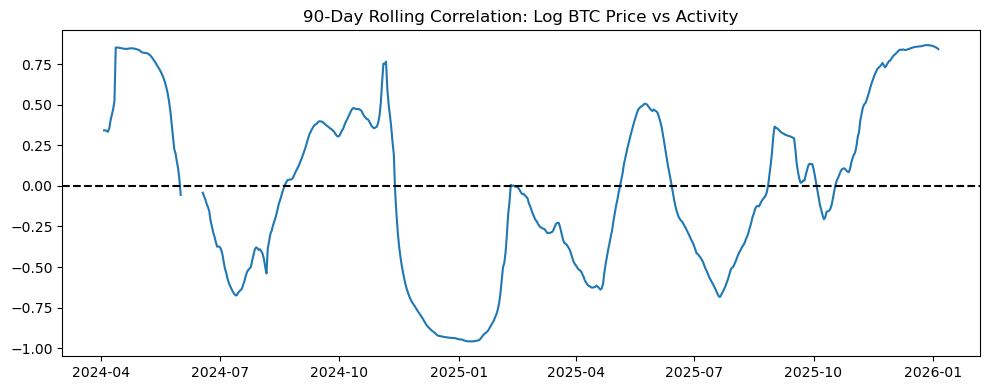

In [48]:
import numpy as np

aligned_df["log_price"] = np.log(aligned_df["PriceUSD"])

corr_log = aligned_df["log_price"].corr(aligned_df["smart_odds_updates"])
print(f"Correlation (Log Price vs Activity): {corr_log}")

rolling_corr = (
    aligned_df["log_price"]
    .rolling(90)
    .corr(aligned_df["smart_odds_updates"])
)

plt.figure(figsize=(10, 4))
plt.plot(rolling_corr)
plt.axhline(0, color="black", linestyle="--")
plt.title("90-Day Rolling Correlation: Log BTC Price vs Activity")
plt.tight_layout()
plt.show()


Key findings:

- Prediction market activity shows a moderate negative correlation (~ −0.47) with Bitcoin price levels.
- Correlations with daily returns and volatility are near zero.
- Rolling correlations indicate persistent regime-level relationships rather than short-term noise.

Interpretation:

Prediction market activity behaves as a counter-cyclical regime signal rather than a short-horizon predictive indicator. Elevated activity tends to occur during lower-price environments and periods of heightened uncertainty.


### 4.3 Accumulation Efficiency Proxy

For accumulation strategies, the goal is not to predict returns, but to improve capital allocation efficiency by allocating more during relatively favorable price environments.

To evaluate whether prediction market activity aligns with such environments, we construct a descriptive proxy:

- Future 30-day minimum price drawdown relative to current price

This measures whether higher activity tends to occur before or during periods with better future buying opportunities.


In [49]:
aligned_df = aligned_df.copy()

aligned_df["future_min_30d"] = (
    aligned_df["PriceUSD"]
    .rolling(window=30, min_periods=1)
    .min()
    .shift(-30)
)

aligned_df["future_drawdown_30d"] = (
    aligned_df["future_min_30d"] / aligned_df["PriceUSD"] - 1
)


In [50]:
aligned_df["activity_quantile"] = pd.qcut(
    aligned_df["smart_odds_updates"],
    q=3,
    labels=["Low Activity", "Medium Activity", "High Activity"]
)

plot_df = aligned_df.dropna(
    subset=["future_drawdown_30d", "activity_quantile"]
)


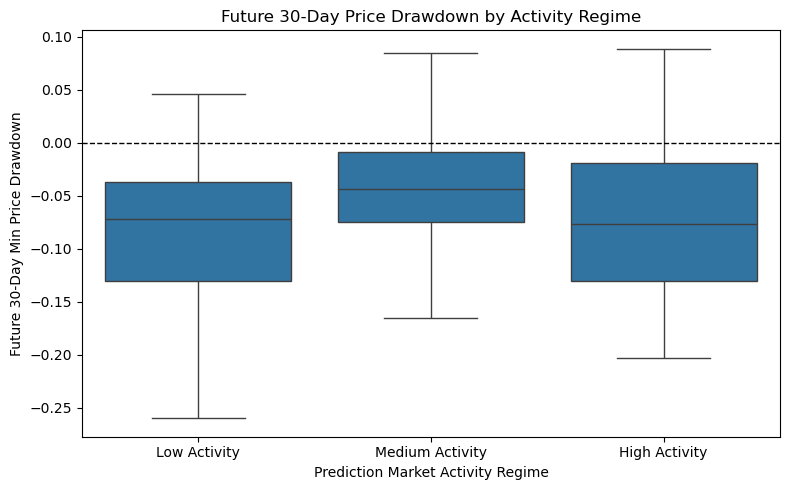

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_df,
    x="activity_quantile",
    y="future_drawdown_30d",
    showfliers=False
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Future 30-Day Price Drawdown by Activity Regime")
plt.xlabel("Prediction Market Activity Regime")
plt.ylabel("Future 30-Day Min Price Drawdown")
plt.tight_layout()
plt.show()


Across all activity regimes, future drawdowns remain predominantly negative, indicating that accumulation opportunities commonly exist regardless of activity level.

Importantly, high prediction market activity does not coincide with systematically worse future buying conditions. In some cases, high-activity regimes exhibit slightly deeper future drawdowns.

Interpretation:

Prediction market activity does not function as a directional return predictor. Instead, it behaves as a contextual regime indicator that may support risk-aware allocation decisions within dynamic accumulation strategies.


## 5. Model-Ready Feature Design & Validation

Having established data integrity, temporal alignment, and exploratory signal relevance, this section outlines how the constructed dataset can be safely transitioned into downstream modeling workflows.

The objective here is not to train or evaluate predictive models. Instead, this section:

- Defines model-ready feature categories
- Specifies time-consistent evaluation splits
- Documents potential leakage risks and mitigation strategies

The intended downstream use case is dynamic, long-only Bitcoin accumulation modeling, where prediction market signals act as contextual conditioning inputs rather than direct return predictors.


### 5.1 Model-Ready Feature Categories

Based on the preceding exploratory analysis, the aligned daily dataset supports three feature categories, each motivated by a distinct role in downstream accumulation modeling.


**1. Bitcoin Market & On-Chain Metrics**

Core daily indicators derived from Coin Metrics, including:

- Price levels
- Transaction activity
- Network usage metrics
- Supply dynamics and exchange flows

These variables provide baseline structural context and serve as primary state features in downstream models.


**2. Aggregated Prediction Market Activity (High-Liquidity Subset)**

Activity- and dispersion-based signals derived from the highest-volume Polymarket markets:

- `smart_odds_updates`
- `smart_price_std`

These features capture market attention, uncertainty, and belief divergence. As shown in Section 4, they exhibit counter-cyclical, regime-level behavior and are treated as contextual conditioning signals.


**3. Contextual Probability Levels (Secondary Features)**

Average probability levels (`smart_mean_price`) provide contextual information about overall market sentiment but are not primary predictive signals due to strong averaging effects across markets.


### 5.2 Temporal Splits & Evaluation Design

Because both Bitcoin and prediction market data are time-series in nature, all downstream modeling must use strictly forward-looking, time-ordered evaluation splits. Random shuffling is explicitly avoided to preserve temporal causality and prevent leakage.

We define a simple chronological split:

- **Train:** earliest 80% of observations (model fitting)
- **Validation:** next 10% (model selection / tuning)
- **Test:** most recent 10% (final held-out evaluation)



In [52]:
# ---- Time-ordered train/val/test split ----
n = len(aligned_df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = aligned_df.iloc[:train_end].copy()
val_df = aligned_df.iloc[train_end:val_end].copy()
test_df = aligned_df.iloc[val_end:].copy()

print("Total:", aligned_df.shape)
print("Train:", train_df.shape, "| dates:", train_df.index.min(), "->", train_df.index.max())
print("Val:  ", val_df.shape,   "| dates:", val_df.index.min(),   "->", val_df.index.max())
print("Test: ", test_df.shape,  "| dates:", test_df.index.min(),  "->", test_df.index.max())


Total: (732, 39)
Train: (585, 39) | dates: 2024-01-05 -> 2025-08-11
Val:   (73, 39) | dates: 2025-08-12 -> 2025-10-23
Test:  (74, 39) | dates: 2025-10-24 -> 2026-01-05


### 5.3 Leakage & Look-Ahead Risk Assessment

Several potential sources of leakage were explicitly considered and mitigated:


- All prediction market features are constructed using same-day information only and do not incorporate future odds updates.

- Timestamp normalization ensures that prediction market events are aligned strictly by calendar date, preventing inadvertent inclusion of intra-day future information.

- Forward-looking quantities (e.g., future drawdowns) are computed using explicit temporal shifts and are never included as input features.

- Aggregation is performed at a daily level, reducing microstructure noise and minimizing implicit look-ahead bias.


### 5.4 Readiness Summary

The resulting dataset consists of temporally aligned, leakage-aware daily features spanning Bitcoin market metrics and high-liquidity prediction market activity.

While no predictive claims are made at this stage, the dataset is structurally suitable for downstream modeling, regime analysis, and decision-support experimentation in later project phases.

In particular, prediction market activity signals demonstrate potential value as contextual conditioning inputs within volatility-aware, long-only Bitcoin accumulation frameworks.
